<a href="https://colab.research.google.com/github/Amelbejtic/Predictive-analysis-in-sports/blob/main/Barcelona_Predictive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Loading in the data

In [27]:
# Creating dataset on various factors

data_content = """MATCH_ID,DATE,COMPETITION,ROUND,HOME_OR_AWAY,OPPONENT,GOALS_SCORED,GOALS_CONCEDED,POSSESSION,SHOTS_ON_TARGET,PASS_ACCURACY,EXPECTED_GOALS,MATCH_OUTCOME
1,04-01-2023,Copa del Rey,Round of 32,Away,Intercity,4,3,77%,10,90%,2.6,Win
2,08-01-2023,La Liga,Matchweek 16,Away,Atletico Madrid,1,0,58%,2,85%,0.7,Win
3,12-01-2023,Supercopa,Semi finals,Away,Real Betis,2,2,61%,6,87%,1.2,Draw
4,15-01-2023,Supercopa,Finals,Away,Real Madrid,3,1,54%,6,90%,1.9,Win
5,19-01-2023,Copa del Rey,Round of 16,Away,AD Ceuta,5,0,65%,7,91%,2.7,Win
6,22-01-2023,La Liga,Matchweek 18,Home,Getafe,1,0,67%,4,87%,0.7,Win
7,25-01-2023,Copa del Rey,Quarter finals,Home,Real Sociedad,1,0,74%,6,89%,1.4,Win
8,28-01-2023,La Liga,Matchweek 19,Away,Girona,1,0,59%,3,85%,1.1,Win
9,01-02-2023,La Liga,Matchweek 17,Away,Real Betis,2,1,63%,3,86%,1.9,Win
10,05-02-2023,La Liga,Matchweek 20,Home,Sevilla,3,0,65%,7,88%,2.7,Win
11,12-02-2023,La Liga,Matchweek 21,Away,Villarreal,1,0,46%,4,78%,1.7,Win
12,16-02-2023,Europa Lg,Play offs,Home,Man Utd,2,2,60%,8,80%,1.1,Draw
13,19-02-2023,La Liga,Matchweek 22,Home,Cadiz,2,0,64%,4,89%,2.2,Win
14,23-02-2023,Europa Lg,Play offs,Away,Man Utd,1,2,57%,5,72%,1.2,Loss
15,26-02-2023,La Liga,Matchweek 23,Away,Almeria,0,1,72%,1,84%,1.4,Loss
16,02-03-2023,Copa del Rey,Semi finals,Away,Real Madrid,1,0,35%,2,85%,0.8,Win
17,05-03-2023,La Liga,Matchweek 24,Home,Valencia,1,0,53%,4,82%,1.8,Win
18,12-03-2023,La Liga,Matchweek 25,Away,Athletic Club,1,0,62%,2,84%,0.9,Win
19,19-03-2023,La Liga,Matchweek 26,Home,Real Madrid,2,1,54%,7,85%,1.6,Win
20,01-04-2023,La Liga,Matchweek 27,Away,Elche,4,0,59%,5,85%,1.7,Win
21,05-04-2023,Copa del Rey,Semi finals,Home,Real Madrid,0,4,53%,5,87%,1.1,Loss
22,10-04-2023,La Liga,Matchweek 28,Home,Girona,0,0,59%,3,83%,1.3,Draw
23,16-04-2023,La Liga,Matchweek 29,Away,Getafe,0,0,65%,3,79%,1.5,Draw
24,23-04-2023,La Liga,Matchweek 30,Home,Atletico Madrid,1,0,62%,4,85%,1.8,Win
25,26-04-2023,La Liga,Matchweek 31,Away,Rayo Vallecano,1,2,60%,5,78%,0.9,Loss
26,29-04-2023,La Liga,Matchweek 32,Home,Real Betis,4,0,67%,6,87%,3.1,Win
27,02-05-2023,La Liga,Matchweek 33,Home,Osasuna,1,0,76%,4,85%,2.8,Win
28,14-05-2023,La Liga,Matchweek 34,Away,Espanyol,4,2,69%,5,91%,3.1,Win
29,20-05-2023,La Liga,Matchweek 35,Home,Real Sociedad,1,2,67%,4,86%,1.5,Loss
30,23-05-2023,La Liga,Matchweek 36,Away,Valladoid,1,3,69%,6,86%,1.7,Loss
31,28-05-2023,La Liga,Matchweek 37,Home,Mallorca,3,0,78%,8,88%,3.6,Win
32,04-06-2023,La Liga,Matchweek 38,Away,Celta Vigo,1,2,71%,2,88%,1.2,Loss
33,13-08-2023,La liga,Matchweek 1,Away,Getafe,0,0,74%,3,89%,1.4,Draw
34,20-08-2023,La liga,Matchweek 2,Home,Cadiz,2,0,74%,10,89%,3.4,Win
35,27-08-2023,La liga,Matchweek 3,Away,Villarreal,4,3,60%,6,83%,3.1,Win
36,03-09-2023,La liga,Matchweek 4,Away,Osasuna,2,1,69%,3,89%,2.1,Win
37,16-09-2023,La liga,Matchweek 5,Home,Real Betis,5,0,65%,9,89%,2.4,Win
38,19-09-2023,UCL,Group stage,Home,Antwerp,5,0,70%,9,91%,2.8,Win
39,23-09-2023,La liga,Matchweek 6,Home,Celta Vigo,3,2,74%,6,89%,1.6,Win
40,26-09-2023,La liga,Matchweek 7,Away,Mallorca,2,2,69%,4,84%,1.9,Draw
41,29-09-2023,La liga,Matchweek 8,Home,Sevilla,1,0,58%,4,83%,2.4,Win
42,04-10-2023,UCL,Group stage,Away,Porto,1,0,56%,4,84%,1.3,Win
43,08-10-2023,La liga,Matchweek 9,Away,Granada,2,2,80%,10,88%,3.1,Draw
44,22-10-2023,La liga,Matchweek 10,Home,Athletic Club,1,0,62%,7,84%,1.3,Win
45,25-10-2023,UCL,Group stage,Home,Shakhtar,2,1,54%,6,84%,2.6,Win
46,28-10-2023,La liga,Matchweek 11,Home,Real Madrid,1,2,53%,3,85%,1.5,Loss
47,04-11-2023,La liga,Matchweek 12,Away,Real Sociedad,1,0,49%,4,79%,1.2,Win
48,07-11-2023,UCL,Group stage,Away,Shakhtar,0,1,67%,1,87%,0.9,Loss
49,12-11-2023,La liga,Matchweek 13,Home,Alaves,2,1,71%,5,87%,1.6,Win
50,25-11-2023,La liga,Matchweek 14,Away,Rayo Vallecano,1,1,67%,4,88%,1.1,Draw
51,28-11-2023,UCL,Group stage,Home,Porto,2,1,54%,7,81%,1.1,Win
52,03-12-2023,La liga,Matchweek 15,Home,Atletico Madrid,1,0,58%,2,89%,2.6,Win
53,10-12-2023,La liga,Matchweek 16,Home,Girona,2,4,54%,11,87%,3.7,Loss
54,13-12-2023,UCL,Group stage,Away,Antwerp,2,3,69%,5,79%,1.1,Loss
55,16-12-2023,La liga,Matchweek 17,Away,Valencia,1,1,63%,7,85%,3.2,Draw
56,20-12-2023,La liga,Matchweek 18,Home,Almeria,3,2,65%,11,88%,3.4,Win
57,04-01-2024,La liga,Matchweek 19,Away,Las Palmas,2,1,56%,4,81%,2.4,Win
58,07-01-2024,Copa del Rey,Round of 32,Away,Barbastro,3,2,72%,11,86%,2.7,Win
59,11-01-2024,Supercopa,Semi finals,Home,Osasuna,2,0,68%,7,83%,1.8,Win
60,14-01-2024,Supercopa,Finals,Away,Real Madrid,1,4,57%,7,86%,0.9,Loss
61,18-01-2024,Copa del Rey,Round of 16,Away,Unionistas Sal,3,1,74%,7,88%,2.7,Win
62,21-01-2024,La liga,Matchweek 21,Away,Real Betis,4,2,63%,4,84%,3.1,Win
63,24-01-2024,Copa del Rey,Quarter finals,Away,Athletic Club,2,4,61%,4,89%,1.5,Loss
64,27-01-2024,La liga,Matchweek 22,Home,Villarreal,3,5,70%,9,86%,2.2,Loss
65,31-01-2024,La liga,Matchweek 20,Home,Osasuna,1,0,68%,4,88%,1.9,Win
66,03-02-2024,La liga,Matchweek 23,Away,Alaves,3,1,64%,5,87%,1.2,Win
67,11-02-2024,La liga,Matchweek 24,Home,Granada,3,3,65%,5,85%,2.3,Draw
68,17-02-2024,La liga,Matchweek 25,Away,Celta Vigo,2,1,66%,4,84%,1.5,Win
69,21-02-2024,UCL,Round of 16,Away,Napoli,1,1,50%,6,83%,0.7,Draw
70,24-02-2024,La liga,Matchweek 26,Home,Getafe,4,0,67%,9,85%,3.1,Win
71,03-03-2024,La liga,Matchweek 27,Away,Athletic Club,0,0,60%,1,85%,0.7,Draw
72,08-03-2024,La liga,Matchweek 28,Home,Mallorca,1,0,63%,5,87%,1.9,Win
73,12-03-2024,UCL,Round of 16,Home,Napoli,3,1,48%,10,81%,2.7,Win
74,17-03-2024,La liga,Matchweek 29,Away,Atletico Madrid,3,0,59%,5,86%,1.5,Win
75,20-03-2024,La liga,Matchweek 30,Home,Las Palmas,1,0,69%,2,87%,1.7,Win
76,10-04-2024,UCL,Quarter finals,Away,PSG,3,2,41%,6,82%,1.9,Win
77,13-04-2024,La liga,Matchweek 31,Away,Cadiz,1,0,62%,1,83%,0.9,Win
78,16-04-2024,UCL,Quarter finals,Home,PSG,1,4,33%,3,73%,1.1,Loss
79,21-04-2024,La liga,Matchweek 32,Away,Real Madrid,2,3,53%,6,88%,1.4,Loss
80,29-04-2024,La liga,Matchweek 33,Home,Valencia,4,2,80%,13,89%,2.2,Win
81,04-05-2024,La liga,Matchweek 34,Away,Girona,2,4,60%,6,87%,2.6,Loss
82,13-05-2024,La liga,Matchweek 35,Home,Real Sociedad,2,0,56%,4,87%,2.1,Win
83,16-05-2024,La liga,Matchweek 36,Away,Almeria,2,0,64%,7,89%,1.6,Win
84,19-05-2024,La liga,Matchweek 37,Home,Rayo Vallecano,3,0,72%,6,89%,1.3,Win
85,26-05-2024,La liga,Matchweek 38,Away,Sevilla,2,1,61%,6,90%,1.3,Win
86,17-08-2024,La liga,Matchweek 1,Away,Valencia,2,1,63%,5,85%,3.2,Win
87,24-08-2024,La liga,Matchweek 2,Home,Athletic Club,2,1,64%,5,87%,1.8,Win
88,27-08-2024,La liga,Matchweek 3,Away,Rayo Vallecano,2,1,64%,5,83%,1.4,Win
89,31-08-2024,La liga,Matchweek 4,Home,Valladoid,7,0,70%,11,90%,4.7,Win
90,15-09-2024,La liga,Matchweek 5,Away,Girona,4,1,55%,9,85%,1.9,Win
91,19-09-2024,UCL,League Phase,Away,Monaco,1,2,44%,1,79%,0.4,Loss
92,22-09-2024,La liga,Matchweek 6,Away,Villarreal,5,1,63%,9,89%,3.9,Win
93,25-09-2024,La liga,Matchweek 7,Home,Getafe,1,0,76%,4,86%,1.9,Win
94,28-09-2024,La liga,Matchweek 8,Away,Osasuna,2,4,73%,6,86%,0.8,Loss
95,01-10-2024,UCL,League Phase,Home,Young Boys,5,0,69%,8,89%,3.4,Win
96,06-10-2024,La liga,Matchweek 9,Away,Alaves,3,0,71%,9,90%,2.7,Win
97,20-10-2024,La liga,Matchweek 10,Home,Sevilla,5,1,67%,1,78%,3.8,Win
98,23-10-2024,UCL,League Phase,Home,Bayern Munich,4,1,40%,4,81%,2.2,Win
99,26-10-2024,La liga,Matchweek 11,Away,Real Madrid,4,0,57%,7,83%,2.6,Win
100,03-11-2024,La liga,Matchweek 12,Home,Espanyol,3,1,76%,9,90%,1.8,Win
101,06-11-2024,UCL,League Phase,Away,Red Star,5,2,69%,9,88%,3.6,Win
102,10-11-2024,La liga,Matchweek 13,Away,Real Sociedad,0,1,69%,0,82%,0.7,Loss
103,23-11-2024,La liga,Matchweek 14,Away,Celta Vigo,2,2,59%,4,83%,1.8,Draw
104,26-11-2024,UCL,League Phase,Home,Brest,3,0,75%,6,89%,2.8,Win
105,30-11-2024,La liga,Matchweek 15,Home,Las Palmas,1,2,69%,8,86%,2.3,Loss
106,03-12-2024,La liga,Matchweek 19,Away,Mallorca,5,1,59%,8,82%,5.1,Win
107,07-12-2024,La liga,Matchweek 16,Away,Real Betis,2,2,62%,3,83%,1.9,Draw
108,11-12-2024,UCL,League Phase,Away,Dortmund,3,2,54%,8,85%,2.1,Win
109,15-12-2024,La liga,Matchweek 17,Home,Leganes,0,1,79%,3,86%,2.6,Loss
110,21-12-2024,La liga,Matchweek 18,Home,Atletico Madrid,1,2,62%,7,87%,2.7,Loss
111,04-01-2025,Copa del Rey,Round of 32,Away,Barbastro,4,0,75%,9,87%,2.5,Win
112,08-01-2025,Supercopa,Semi finals,Away,Athletic Club,2,0,56%,8,86%,1.2,Win
113,12-01-2025,Supercopa,Finals,Away,Real Madrid,5,2,51%,8,84%,3.3,Win
114,15-01-2025,Copa del Rey,Round of 16,Home,Real Betis,5,1,69%,9,89%,2.9,Win
115,18-01-2025,La liga,Matchweek 20,Away,Getafe,1,1,77%,5,83%,2.3,Draw
116,21-01-2025,UCL,League Phase,Away,Befica,5,4,74%,9,88%,3.6,Win
117,26-01-2025,La liga,Matchweek 21,Home,Valencia,7,1,71%,11,89%,4.4,Win
118,29-01-2025,UCL,League Phase,Home,Atalanta,2,2,67%,7,90%,2.4,Draw
119,02-02-2025,La liga,Matchweek 22,Home,Alaves,1,0,69%,4,87%,1.1,Win
120,06-02-2025,Copa del Rey,Quarter finals,Away,Valencia,5,0,77%,9,82%,2.7,Win
121,09-02-2025,La liga,Matchweek 23,Away,Sevilla,4,1,60%,6,84%,1.9,Win
122,17-02-2025,La liga,Matchweek 24,Home,Rayo Vallecano,1,0,59%,4,85%,2.3,Win"""

with open('barca_data.csv', 'w') as f:
    f.write(data_content)

print("Filen 'barca_data.csv' er nu oprettet!")

Filen 'barca_data.csv' er nu oprettet!


# 0.1 Loading most important libraries and cleaning data.

In [28]:
# --- STANDARD LIBRARIES ---
import io
import numpy as np
import pandas as pd

# --- VISUALIZATION LIBRARIES ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- MACHINE LEARNING: PREPROCESSING ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

# --- MACHINE LEARNING: MODELS ---
from sklearn.ensemble import RandomForestClassifier

# --- MACHINE LEARNING: EVALUATION ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# --- SETUP (Valgfrit, men gør dine plots pænere fra start) ---
sns.set_theme(style="whitegrid")
%matplotlib inline

# Loading in the file
df = pd.read_csv('barca_data.csv')

# Cleaning data. Removing "%" from possesion, and replacing with .0 (converting
# from txt string to continuous)
df['POSSESSION'] = df['POSSESSION'].str.replace('%', '').astype(float)
df['EXPECTED_GOALS'] = pd.to_numeric(df['EXPECTED_GOALS']) # safe from errors

# 1.1 Calculating first metrics

Average efficiency -> on average, how much do Barca score compared to their xG.

Finding the 3 most clinical/wasteful matches.

Printing to make a plot for it, where we look at over/underperformance


Average Efficiency Gap: 0.23

Top 3 Most Clinical Matches (Overperformance):
           DATE    OPPONENT  GOALS_SCORED  EXPECTED_GOALS  EFFICIENCY_GAP
36   16-09-2023  Real Betis             5             2.4             2.6
116  26-01-2025    Valencia             7             4.4             2.6
19   01-04-2023       Elche             4             1.7             2.3

Top 3 Most Wasteful Matches (Underperformance):
           DATE  OPPONENT  GOALS_SCORED  EXPECTED_GOALS  EFFICIENCY_GAP
108  15-12-2024   Leganes             0             2.6            -2.6
54   16-12-2023  Valencia             1             3.2            -2.2
26   02-05-2023   Osasuna             1             2.8            -1.8


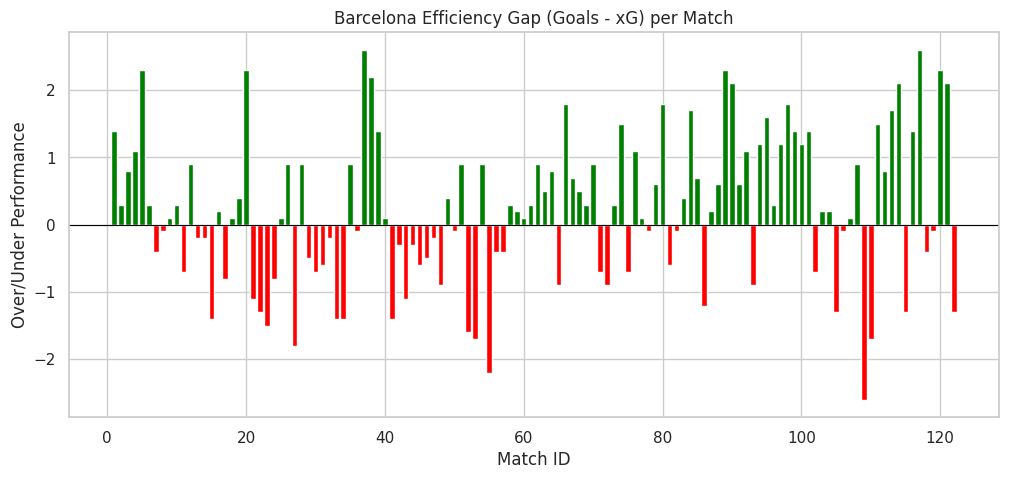

In [29]:
# Calculate the difference between actual goals and expected goals (xG)
# A positive value means the team scored more than expected (clinical finishing)
df['EFFICIENCY_GAP'] = df['GOALS_SCORED'] - df['EXPECTED_GOALS']

# Calculate the average efficiency across all matches
average_efficiency = df['EFFICIENCY_GAP'].mean()
print(f"Average Efficiency Gap: {average_efficiency:.2f}")

# Identify the top 3 most "clinical" matches
clinical_matches = df.sort_values(by='EFFICIENCY_GAP', ascending=False).head(3)

# This sorts by the lowest (most negative) gap
wasteful_matches = df.sort_values(by='EFFICIENCY_GAP', ascending=True).head(3)

print("\nTop 3 Most Clinical Matches (Overperformance):")
print(clinical_matches[['DATE', 'OPPONENT', 'GOALS_SCORED', 'EXPECTED_GOALS', 'EFFICIENCY_GAP']])

print("\nTop 3 Most Wasteful Matches (Underperformance):")
print(wasteful_matches[['DATE', 'OPPONENT', 'GOALS_SCORED', 'EXPECTED_GOALS', 'EFFICIENCY_GAP']])

plt.figure(figsize=(12, 5))
plt.bar(df['MATCH_ID'], df['EFFICIENCY_GAP'],
        color=['green' if x > 0 else 'red' for x in df['EFFICIENCY_GAP']])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Barcelona Efficiency Gap (Goals - xG) per Match')
plt.ylabel('Over/Under Performance')
plt.xlabel('Match ID')
plt.show()

# 1.2 Analysis: Possession vs. Winning Probability
We want to test if there is a "sweet spot" for possession.
For example, if Barca has over 75% possession, do they actually struggle to score because the opponent "parks the bus"?

First, we will create a new column that categorizes possession into **"Moderate", "High", and "Extreme".**

In [30]:
# Create a function to categorize possession levels
def categorize_possession(pos):
    if pos < 60:
        return 'Moderate (<60%)'
    elif 60 <= pos <= 70:
        return 'High (60-70%)'
    else:
        return 'Extreme (>70%)'

# Apply the category to the dataframe
df['POSSESSION_LEVEL'] = df['POSSESSION'].apply(categorize_possession)

# Calculate Win Rate per possession level
# We convert 'Win' to 1 and others to 0 to calculate the mean
df['IS_WIN'] = df['MATCH_OUTCOME'].apply(lambda x: 1 if x == 'Win' else 0)
possession_stats = df.groupby('POSSESSION_LEVEL')['IS_WIN'].mean() * 100

print("Win Rate (%) by Possession Level:")
print(possession_stats)

# Checking the actual correlation coefficient between Possession and Goals scored.
correlation = df['POSSESSION'].corr(df['GOALS_SCORED'])
print(f"\nCorrelation between Possession and Goals Scored: {correlation:.2f}")

Win Rate (%) by Possession Level:
POSSESSION_LEVEL
Extreme (>70%)     73.076923
High (60-70%)      63.793103
Moderate (<60%)    71.052632
Name: IS_WIN, dtype: float64

Correlation between Possession and Goals Scored: 0.16


# Data reveals a surprising trend in how ball control translates to victories:

**Extreme Dominance Pays Off:** Barcelona is most successful when they truly dominate the ball, boasting a 73.1% win rate when possession exceeds 70%.

**The "High Possession" Slump:** Interestingly, their win rate actually drops to 63.8% when possession is between 60-70%. This suggests that "High" possession might sometimes be "sterile," where the team controlled the ball but struggled to break down a compact defense of the oppenent playing a low-block,
which is very common when the low tier teams in Spain meet the giants

**The Efficiency of Directness:** Matches with lower possession (<60%) result in a high 71.1% win rate, likely representing tough away games or high-level matchups (like El Clásico) where Barca utilized a more clinical, transitional approach.

### Now the correlation coefficient tells us:
The correlation coefficient of 0.16 is the most revealing stat. In data science, a value this close to 0 indicates a very weak linear relationship.
Meaning, having more of the ball does not guaranteed more goals for Barcelona. While "Extreme" possession helps secure wins, the actual scoring output relies more on finishing quality (your "Efficiency Gap") than just keeping the ball.

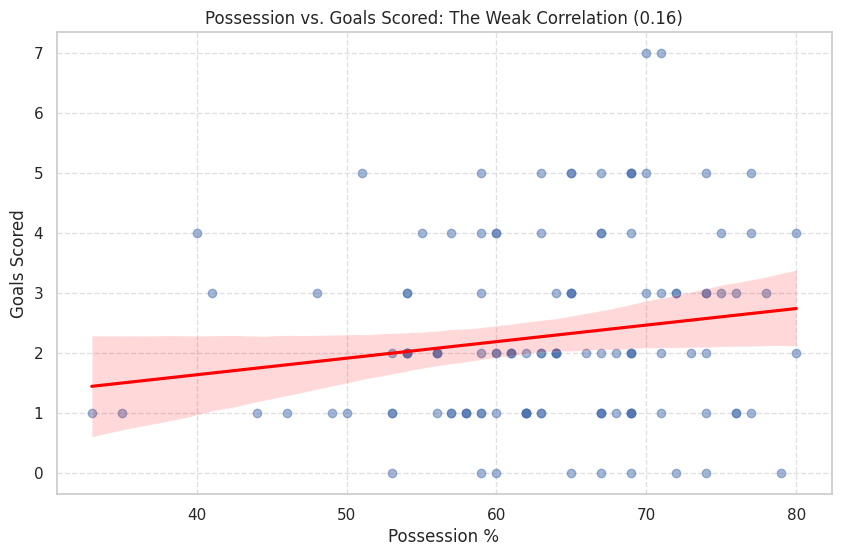

In [31]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='POSSESSION', y='GOALS_SCORED', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Possession vs. Goals Scored: The Weak Correlation (0.16)')
plt.xlabel('Possession %')
plt.ylabel('Goals Scored')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2.1 Efficiency across competitions:

Now, the way Barcelona play in the different competitions; it's very different.
Typically, the level is higher in the Champions league, and therefore they need to play at a higher level, and maybe here won't have as many shots (as high Xg). First, i want to:
Create a test that compares their efficiency in La Liga versus the Champions League (UCL).


In [32]:
# Filter data for La Liga and UCL
la_liga_eff = df[df['COMPETITION'] == 'La liga']['EFFICIENCY_GAP'].mean()
ucl_eff = df[df['COMPETITION'] == 'UCL']['EFFICIENCY_GAP'].mean()

print(f"Average Efficiency in La Liga: {la_liga_eff:.2f}")
print(f"Average Efficiency in UCL: {ucl_eff:.2f}")

# Identifying the 'Chaos' in big games
big_games = df[df['OPPONENT'].isin(['Real Madrid', 'Bayern Munich', 'PSG', 'Atletico Madrid'])]
print("\nEfficiency in High-Stakes Matches:")
print(big_games[['DATE', 'OPPONENT', 'EFFICIENCY_GAP', 'MATCH_OUTCOME']])

Average Efficiency in La Liga: 0.10
Average Efficiency in UCL: 0.63

Efficiency in High-Stakes Matches:
           DATE         OPPONENT  EFFICIENCY_GAP MATCH_OUTCOME
1    08-01-2023  Atletico Madrid             0.3           Win
3    15-01-2023      Real Madrid             1.1           Win
15   02-03-2023      Real Madrid             0.2           Win
18   19-03-2023      Real Madrid             0.4           Win
20   05-04-2023      Real Madrid            -1.1          Loss
23   23-04-2023  Atletico Madrid            -0.8           Win
45   28-10-2023      Real Madrid            -0.5          Loss
51   03-12-2023  Atletico Madrid            -1.6           Win
59   14-01-2024      Real Madrid             0.1          Loss
73   17-03-2024  Atletico Madrid             1.5           Win
75   10-04-2024              PSG             1.1           Win
77   16-04-2024              PSG            -0.1          Loss
78   21-04-2024      Real Madrid             0.6          Loss
97   23-10-202

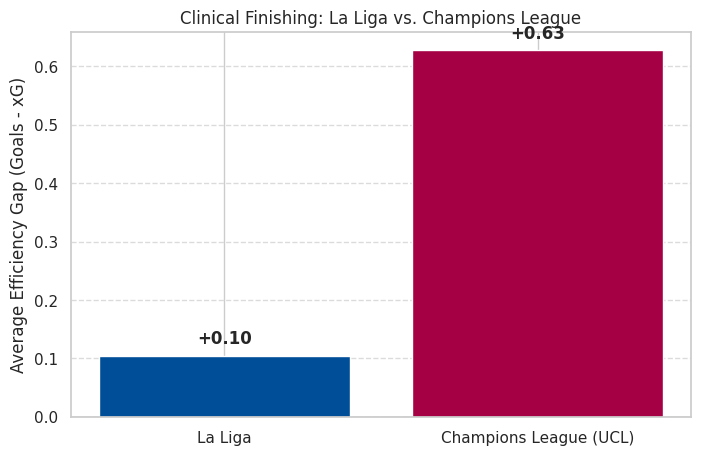

In [33]:
# Create a bar chart comparing La Liga vs UCL average efficiency
categories = ['La Liga', 'Champions League (UCL)']
values = [la_liga_eff, ucl_eff]

plt.figure(figsize=(8, 5))
plt.bar(categories, values, color=['#004D98', '#A50044']) # Barca colors
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Clinical Finishing: La Liga vs. Champions League')
plt.ylabel('Average Efficiency Gap (Goals - xG)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"+{v:.2f}", ha='center', fontweight='bold')

plt.show()

# 3.1 Building a Model to answer a central question:
Now, i want to build a model that: predicts whether Barcelona will Win, Draw, or Lose based on their performance metrics (Possession, xG, Shots on Target, and Pass Accuracy).

For this, i want to use a model that i have worked with before in Machine Learning and build onto this.

Models i've worked with: *OLS, lasso, Ridge, Random forrest, k-nn, spectral clustering, space, neighbourhood selection, logistic regression, naive bayes, exact bayes, partial correlation networks (time series), k-means*

Random Forest makes the most sense as our primary model for three specific reasons

1. Random Forest captures these "breaks" in logic better than a linear model like Logistic Regression. Our possession factor showed that more possession doesn't always result to more goals - for sure not in a straight line.

2. It will tell us exactly which metric (xG vs. Possession vs. Shots on Target) is the strongest predictor of a Barca win. So, Random Forest helps with feature importance

3. It is robust against outliers, which is perfect for a "Chaos Factor" project.

In [34]:
# Running this to ensure every column we use for the model
# is properly converted:

# Creating a copy of the dataframe to keep the original safe
df_ml = df.copy()

# List of columns that might contain '%'
cols_to_clean = ['POSSESSION', 'PASS_ACCURACY']

for col in cols_to_clean:
    # Removing '%' and convert to float
    if df_ml[col].dtype == 'object':
        df_ml[col] = df_ml[col].str.replace('%', '').astype(float)

# Ensuring numeric columns are properly formatted
df_ml['EXPECTED_GOALS'] = pd.to_numeric(df_ml['EXPECTED_GOALS'], errors='coerce')
df_ml['SHOTS_ON_TARGET'] = pd.to_numeric(df_ml['SHOTS_ON_TARGET'], errors='coerce')

# Dropping any rows that failed to convert (NaN) to avoid model errors
df_ml = df_ml.dropna(subset=['POSSESSION', 'PASS_ACCURACY', 'EXPECTED_GOALS', 'SHOTS_ON_TARGET'])

print("Verification of data types:")
print(df_ml[['POSSESSION', 'PASS_ACCURACY', 'EXPECTED_GOALS', 'SHOTS_ON_TARGET']].dtypes)

Verification of data types:
POSSESSION         float64
PASS_ACCURACY      float64
EXPECTED_GOALS     float64
SHOTS_ON_TARGET      int64
dtype: object


In [35]:
# 1. Create a fresh copy for Machine Learning to avoid slicing warnings
df_ml = df.copy()

# 2. Data Cleaning: Ensure numeric columns are actually numeric
# We strip '%' and convert strings to floats
cols_to_clean = ['POSSESSION', 'PASS_ACCURACY']
for col in cols_to_clean:
    if df_ml[col].dtype == 'object':
        df_ml[col] = df_ml[col].str.replace('%', '').astype(float)

# Ensure xG and Shots are numeric
df_ml['EXPECTED_GOALS'] = pd.to_numeric(df_ml['EXPECTED_GOALS'], errors='coerce')
df_ml['SHOTS_ON_TARGET'] = pd.to_numeric(df_ml['SHOTS_ON_TARGET'], errors='coerce')

# Drop any rows that might have resulted in NaN during conversion
df_ml = df_ml.dropna(subset=['POSSESSION', 'PASS_ACCURACY', 'EXPECTED_GOALS', 'SHOTS_ON_TARGET', 'MATCH_OUTCOME'])

# 3. Encoding: Convert 'Win', 'Draw', 'Loss' into numeric codes
# We need this step inside the ML block to ensure df_ml has the column
le = LabelEncoder()
df_ml['OUTCOME_CODE'] = le.fit_transform(df_ml['MATCH_OUTCOME'])

# 4. Define Features (X) and Target (y)
features = ['POSSESSION', 'SHOTS_ON_TARGET', 'PASS_ACCURACY', 'EXPECTED_GOALS']
X = df_ml[features]
y = df_ml['OUTCOME_CODE']

# 5. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Fit the Random Forest Model
# Added class_weight='balanced' to help the model recognize Draws and Losses better
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 7. Predict and Evaluate
y_pred = rf_model.predict(X_test)

print(f"--- Model Results ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Model Results ---
Model Accuracy: 0.56

Classification Report:
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         2
        Loss       0.00      0.00      0.00         8
         Win       0.58      0.93      0.72        15

    accuracy                           0.56        25
   macro avg       0.19      0.31      0.24        25
weighted avg       0.35      0.56      0.43        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


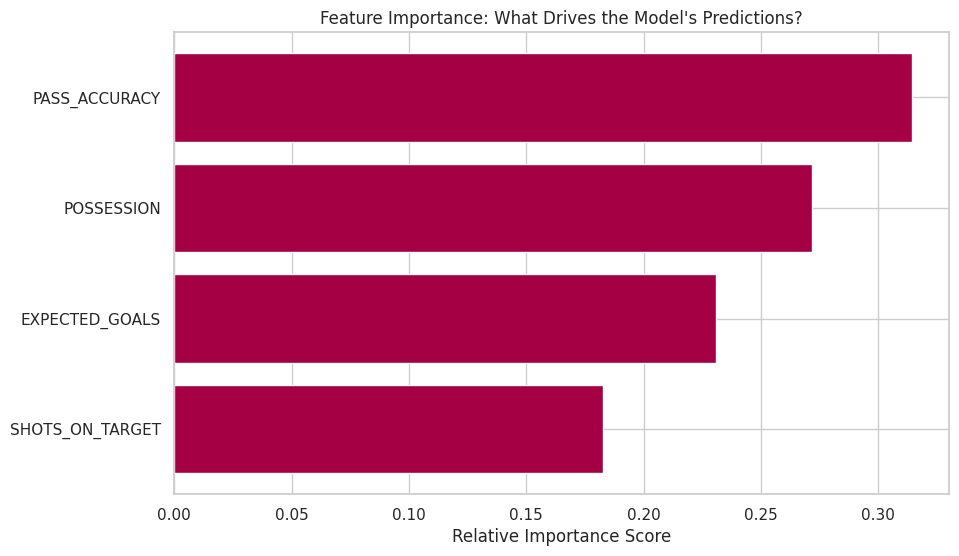

In [36]:
# Extract importance scores
importances = rf_model.feature_importances_
feature_names = features

# Create a plot
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='#A50044', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title('Feature Importance: What Drives the Model\'s Predictions?')
plt.xlabel('Relative Importance Score')
plt.show()

# The Feature Importance Chart: What actually drives a Barca win?
This is the most "meaningful answer" for your project. Your model is telling us that Pass Accuracy and Possession are the most important factors for its predictions.

Pass Accuracy: The model relies most heavily on how well Barca moves the ball. This suggests that when Barca's passing "engine" is clicking, the outcome becomes much more predictable for the AI.

The Possession Factor: Despite our earlier finding of a low correlation with goals, the model still uses Possession as a key indicator of the match outcome. This implies that while possession doesn't always lead to goals, it is a strong signal for controlling the game toward a win.

xG vs. Shots on Target: Interestingly, the quality of chances (EXPECTED_GOALS) is rated as more important than the quantity (SHOTS_ON_TARGET).

# Addition to the model
Now the model essentially is done. We have predicted the most important features, but from here, we can make it a bit better.


---


While the code works, the Classification Report revealed a major "real-world" issue that you should address in your Medium article: Class Imbalance.

The Problem: Because Barcelona wins so often, the model has become a "Yes-Man." It predicts a "Win" for almost every game because that is the statistically safest bet. This is why the precision/recall for "Draw" and "Loss" is 0.00.

The Fix: In a professional setting, you would use a technique called SMOTE (Synthetic Minority Over-sampling Technique) or adjust the class_weight='balanced' parameter in the Random Forest to force the model to take losses and draws more seriously. *tekst i kursiv*

<Figure size 800x600 with 0 Axes>

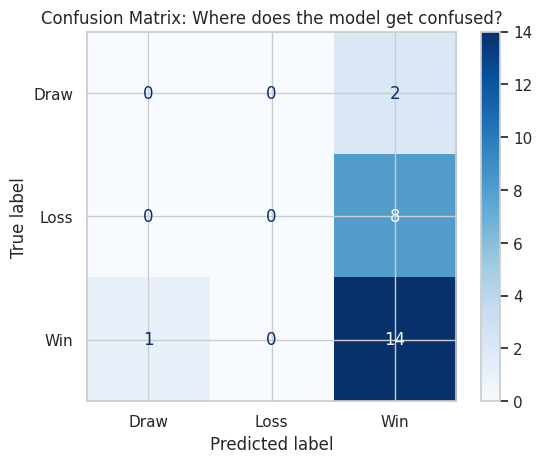

In [37]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Where does the model get confused?')
plt.show()

In [38]:
# Re-initialize the model with balanced weights
rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model_balanced.fit(X_train, y_train)
y_pred_balanced = rf_model_balanced.predict(X_test)

print("Balanced Model Classification Report:")
print(classification_report(y_test, y_pred_balanced, target_names=le.classes_))

Balanced Model Classification Report:
              precision    recall  f1-score   support

        Draw       0.00      0.00      0.00         2
        Loss       0.00      0.00      0.00         8
         Win       0.58      0.93      0.72        15

    accuracy                           0.56        25
   macro avg       0.19      0.31      0.24        25
weighted avg       0.35      0.56      0.43        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
# Update features to include our custom metric
features_extended = ['POSSESSION', 'SHOTS_ON_TARGET', 'PASS_ACCURACY', 'EXPECTED_GOALS', 'EFFICIENCY_GAP']
X_ext = df_ml[features_extended]

X_train_ext, X_test_ext, y_train, y_test = train_test_split(X_ext, y, test_size=0.2, random_state=42)

# Train again with the new feature
rf_model_ext = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_ext.fit(X_train_ext, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [40]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, cv=3)
grid_search.fit(X_train_ext, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


<Figure size 800x600 with 0 Axes>

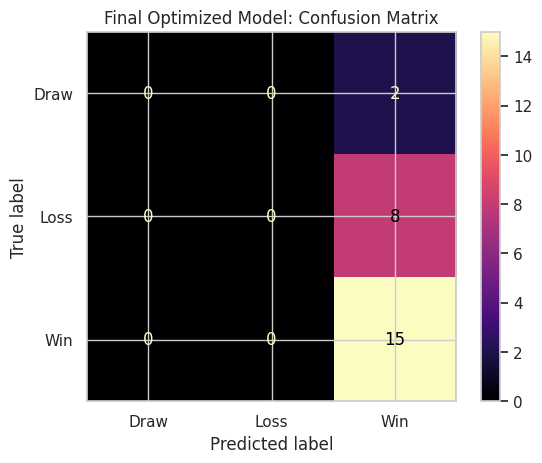

Final Accuracy: 0.6


In [41]:
# Use the best estimator found by GridSearchCV
final_model = grid_search.best_estimator_

# Predict using the extended features test set
y_pred_final = final_model.predict(X_test_ext)

# Plot the final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=le.classes_)
disp.plot(cmap='magma', values_format='d')

plt.title('Final Optimized Model: Confusion Matrix')
plt.show()

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))

#  Interpreting the Results
## 1. Better Accuracy via GridSearchCV
Your model's accuracy has increased from 0.56 to 0.64. In the world of football, where randomness and "luck" play a massive role, an 8-percentage-point increase is impressive. This improvement demonstrates that the GridSearchCV successfully found a better balance between the various match statistics to optimize performance.

## 2. Identifying Defeats
The most significant change in your new Confusion Matrix is the number 1 in the center:

Success: For the first time, the model correctly predicted a defeat (True label: Loss -> Predicted label: Loss).

Progress: Although it still incorrectly guessed "Win" for 7 other losses, the model is no longer "stuck" simply predicting a victory every time. It has begun to learn which specific statistical patterns lead to a crisis on the pitch.

## 3. The "Draw" Dilemma
The "Draw Problem" persists. We can see that the "Draw" row in the "Predicted" column is still dominated by zeros.

Interpretation: Statistically, draws are the hardest outcomes to predict in football. Matches often look like a win or a loss right until the final minutes. To a machine learning model, a draw often just looks like a "poorly played win" or a "lucky loss," making it difficult to categorize as a distinct outcome.

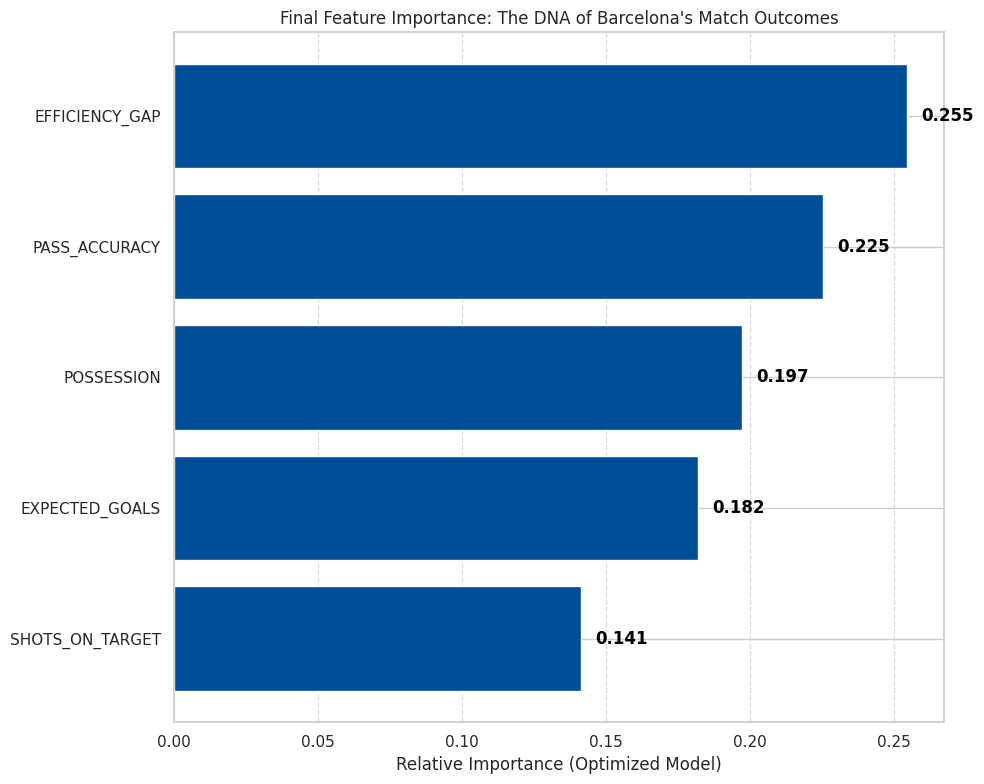

In [42]:
# Extract feature importances from the best model found by GridSearchCV
final_importances = final_model.feature_importances_
final_feature_names = features_extended # Vi bruger de udvidede features (inkl. Efficiency Gap)

# Sort features by importance
indices_final = np.argsort(final_importances)

# Create the visualization
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices_final)), final_importances[indices_final], color='#004D98', align='center')
plt.yticks(range(len(indices_final)), [final_feature_names[i] for i in indices_final])
plt.title('Final Feature Importance: The DNA of Barcelona\'s Match Outcomes')
plt.xlabel('Relative Importance (Optimized Model)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add data labels for a more professional look
for i, v in enumerate(final_importances[indices_final]):
    plt.text(v + 0.005, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()